In [23]:
import sys
sys.path.insert(0, '..')

import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
from IPython.display import display

from src.metrics.limit_cycles import detect_limit_cycle, _trim_trajectory, _vote_tuple

%load_ext autoreload
%autoreload 2

ROOT = Path('..')
BASE = ROOT / 'results' / 'mas' / 'gpqa_full_sim_tier3'

W_VALUES  = [1, 2, 5]
W_COLORS  = {1: '#4C72B0', 2: '#DD8452', 5: '#55A868'}
DS_COLORS = {'gpqa': '#5470C6', 'hiddenbench': '#EE6666'}
datasets  = ['gpqa', 'hiddenbench']

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## What counts as a limit cycle?

A repetition has a limit cycle when the group vote-profile (one vote per agent, e.g. `A A B B`) returns to a configuration it already visited — **after having left it**.

Two exclusions to avoid false positives:
- **Period-1 excluded**: same profile on consecutive rounds just means no one changed their vote (a stall, not an oscillation).
- **Unanimous recurrence excluded**: if the recurring profile is already fully unanimous, it's just the convergence tail, not an oscillation.

The **period** is the number of rounds between first and second visit: period 2 = A-B-A, period 3 = A-B-C-A, etc.

## Load data and detect

In [24]:
def load_window_data(w):
    folder = BASE / f'W{w}_fc'
    by_qid = {}
    for f in sorted(folder.glob('*.json')):
        d = json.loads(f.read_text())
        qid = d['question_id']
        if qid not in by_qid or str(f) > by_qid[qid]['_path']:
            d['_path'] = str(f)
            by_qid[qid] = d
    return by_qid

raw = {w: load_window_data(w) for w in W_VALUES}
common_qids = sorted(set(raw[1].keys()) & set(raw[2].keys()) & set(raw[5].keys()))
print(f'Common qids: {len(common_qids)}')

rows = []
for w, data in raw.items():
    for qid, d in data.items():
        if qid not in common_qids:
            continue
        reps    = d['repetitions']
        dataset = d.get('dataset', 'unknown')
        gt      = d.get('ground_truth', None)

        for rep_idx, rep in enumerate(reps):
            traj   = rep['trajectory']
            T_r    = len(traj) - 1
            result = detect_limit_cycle(traj)
            if result is None:
                continue

            terminal_votes = [traj[T_r]['phase_b'][i]['vote'] for i in range(len(traj[0]['phase_b']))]
            cfg_r0 = '-'.join(str(v) for v in sorted(
                Counter(ag['vote'] for ag in traj[0]['phase_b']).values(), reverse=True
            ))

            # find the oscillating profile for characterisation
            osc_profile = None
            if result['lc']:
                seen = {}
                for t, vt in enumerate(result['seq']):
                    if vt in seen:
                        osc_profile = vt
                        break
                    seen[vt] = t

            rows.append({
                'W': w, 'qid': qid, 'dataset': dataset, 'rep_idx': rep_idx,
                'lc':            result['lc'],
                'period':        result['period'],
                'L':             result['L'],
                'seq_str':       ' → '.join(''.join(v) for v in result['seq']),
                'osc_profile':   ' '.join(osc_profile) if osc_profile else None,
                'cfg_r0':        cfg_r0,
                'final_correct': (terminal_votes[0] == gt) if gt else None,
                'n_rounds':      T_r + 1,
                'total_tokens':  sum(
                    ag.get('prompt_tokens', 0) + ag.get('completion_tokens', 0)
                    for rd in traj for ag in rd['phase_b']
                ),
            })

df = pd.DataFrame(rows)
lc_df = df[df['lc'] == True]

print(f'Total repetitions analysed: {len(df)}')
print(f'Genuine limit cycles:       {df["lc"].sum()} ({df["lc"].mean():.1%})')
print()
display(
    df.groupby(['dataset', 'W'])['lc']
    .agg(lc_rate='mean', n_lc='sum', n_total='count')
    .assign(lc_rate=lambda x: x['lc_rate'].map('{:.1%}'.format))
)

Common qids: 12
Total repetitions analysed: 1250
Genuine limit cycles:       50 (4.0%)



lc_rate  n_lc  n_total
dataset     W                       
gpqa        1    0.8%     1      123
            2    2.2%     3      134
            5    3.7%     5      135
hiddenbench 1    6.2%    19      304
            2    4.0%    11      278
            5    4.0%    11      276

---
## Catalog: every oscillation pattern and how often it occurs

For each detected limit cycle we record:
- the **full sequence** of vote profiles from round 0 to the trimmed end
- the **oscillating profile** (the one that recurs)
- the **period** (gap in rounds between visits)

The table below groups identical oscillating profiles and counts occurrences.

In [25]:
pattern_counts = (
    lc_df.groupby(['osc_profile', 'period'])
    .agg(count=('rep_idx', 'count'), datasets=('dataset', lambda x: ', '.join(sorted(set(x)))))
    .sort_values('count', ascending=False)
    .reset_index()
)
pattern_counts['pct'] = (pattern_counts['count'] / len(lc_df) * 100).round(1).astype(str) + '%'
print(f'Unique oscillating profiles: {len(pattern_counts)}')
print(f'Total LC repetitions:        {len(lc_df)}')
print()
display(pattern_counts.to_string(index=False))

Unique oscillating profiles: 34
Total LC repetitions:        50



'osc_profile  period  count          datasets   pct\n    A B B B     2.0      6       hiddenbench 12.0%\n    A B B B     3.0      3       hiddenbench  6.0%\n    C B B B     2.0      3       hiddenbench  6.0%\n    B B B C     3.0      2       hiddenbench  4.0%\n    A B A A     2.0      2       hiddenbench  4.0%\n    B B B A     3.0      2       hiddenbench  4.0%\n    A A B A     2.0      2 gpqa, hiddenbench  4.0%\n    C B B B     3.0      2       hiddenbench  4.0%\n    A C A A     2.0      2       hiddenbench  4.0%\n    C A C C     2.0      2 gpqa, hiddenbench  4.0%\n    C A A A     2.0      1       hiddenbench  2.0%\n    B C C B     3.0      1       hiddenbench  2.0%\n    B D B B     3.0      1              gpqa  2.0%\n    A A A C     2.0      1       hiddenbench  2.0%\n    C A A C     2.0      1              gpqa  2.0%\n    C B A C     2.0      1       hiddenbench  2.0%\n    B B D D     2.0      1              gpqa  2.0%\n    C C B B     2.0      1       hiddenbench  2.0%\n    C C B C

In [26]:
print('=== Full sequences for the most common oscillating profiles ===')
for _, row in pattern_counts.head(8).iterrows():
    examples = lc_df[lc_df['osc_profile'] == row['osc_profile']]['seq_str'].values[:3]
    print(f'\nProfile [{row["osc_profile"]}]  period={row["period"]}  n={row["count"]}')
    for ex in examples:
        print(f'  {ex}')

=== Full sequences for the most common oscillating profiles ===

Profile [A B B B]  period=2.0  n=6
  ABBB → CABB → ABBB → CBCB → CCBB → BBBB
  ABBB → BABB → BBAA → ABBB → ABBB → AABB → BBBB
  ABBB → BABA → ABBA → ABBB → BBBB

Profile [A B B B]  period=3.0  n=3
  ABBB → CABB → ABBB → CBCB → CCBB → BBBB
  ABBB → BABB → BBAA → ABBB → ABBB → AABB → BBBB
  ABBB → BABA → ABBA → ABBB → BBBB

Profile [C B B B]  period=2.0  n=3
  ABCB → BCBC → CBBB → CBCB → CCBB → CBBB → CBBB → BBBC → CBCC → BCCC → CCCC
  CBBB → BBBB → BBBC → CBBB → BBBB
  CBBB → BBBB → CBBB → BBBB

Profile [B B B C]  period=3.0  n=2
  BBBC → ABCC → ABBC → BBBC → CBBC → CBBC → BBBC → BBBC → BBBC → BBBB
  BBBC → BCCB → CBBB → BBBC → BBBC → BBBC → BBBC → BBBC → BBBC → BBBC → BBBC → BBBB

Profile [A B A A]  period=2.0  n=2
  ABAA → AAAA → ABAA → ABBA → BABA → BBBA → BBBA → BBBA → BBBB
  ABAA → AAAA → ABAA → ABAA → ABAA → ABAA → AAAA

Profile [B B B A]  period=3.0  n=2
  BBBA → AABB → ABBA → BBBA → ABAB → BBBB
  BBBA → BABB → BBBB

---
## Overall LC rate by memory window

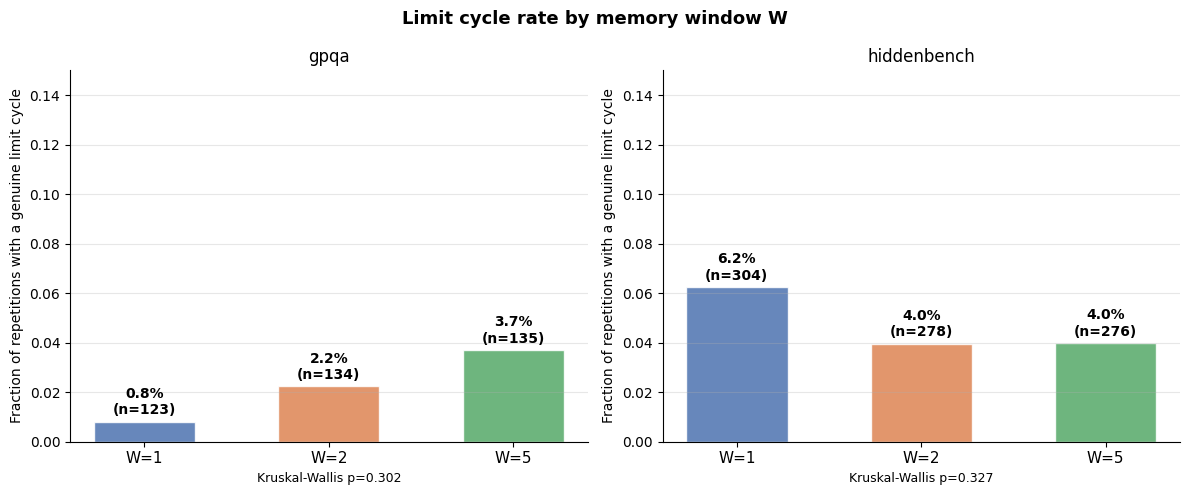

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, ds in zip(axes, datasets):
    sub   = df[df['dataset'] == ds]
    rates = [sub[sub['W'] == w]['lc'].mean() for w in W_VALUES]
    ns    = [len(sub[sub['W'] == w]) for w in W_VALUES]
    ax.bar(range(3), rates, color=[W_COLORS[w] for w in W_VALUES],
           alpha=0.85, edgecolor='white', width=0.55)
    for i, (r, n) in enumerate(zip(rates, ns)):
        ax.text(i, r + 0.003, f'{r:.1%}\n(n={n})', ha='center', fontsize=10, fontweight='bold')
    kw_stat, kw_p = sp_stats.kruskal(*[sub[sub['W'] == w]['lc'].values for w in W_VALUES])
    ax.set_xticks(range(3))
    ax.set_xticklabels([f'W={w}' for w in W_VALUES], fontsize=11)
    ax.set_ylabel('Fraction of repetitions with a genuine limit cycle', fontsize=10)
    ax.set_ylim(0, 0.15)
    ax.set_title(f'{ds}', fontsize=12)
    ax.set_xlabel(f'Kruskal-Wallis p={kw_p:.3f}', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Limit cycle rate by memory window W', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Period distribution

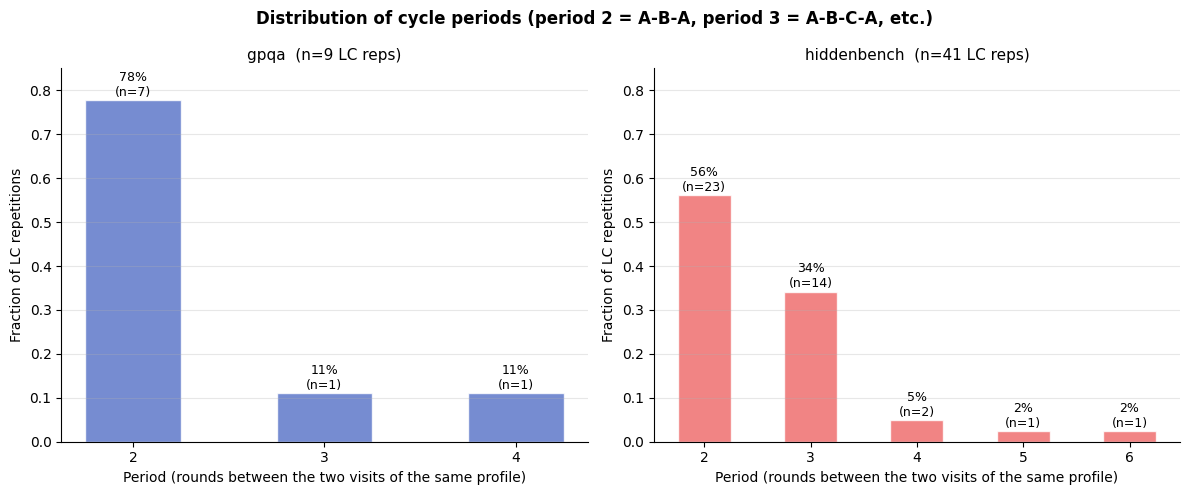

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, ds in zip(axes, datasets):
    sub   = lc_df[lc_df['dataset'] == ds]
    cnt   = Counter(sub['period'].dropna().astype(int))
    total = sum(cnt.values())
    xs    = sorted(cnt)
    ax.bar(xs, [cnt[x] / total for x in xs],
           color=DS_COLORS[ds], alpha=0.8, edgecolor='white', width=0.5)
    for x in xs:
        ax.text(x, cnt[x] / total + 0.01, f'{cnt[x]/total:.0%}\n(n={cnt[x]})', ha='center', fontsize=9)
    ax.set_xlabel('Period (rounds between the two visits of the same profile)', fontsize=10)
    ax.set_ylabel('Fraction of LC repetitions', fontsize=10)
    ax.set_title(f'{ds}  (n={len(sub)} LC reps)', fontsize=11)
    ax.set_xticks(xs)
    ax.set_ylim(0, 0.85)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Distribution of cycle periods (period 2 = A-B-A, period 3 = A-B-C-A, etc.)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Starting configuration and LC rate

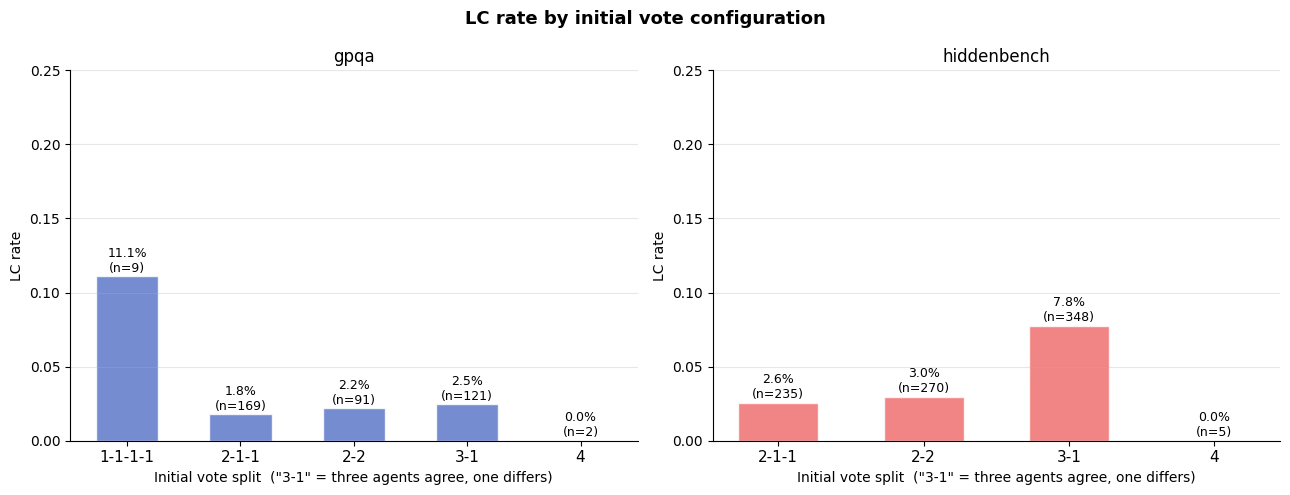

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, ds in zip(axes, datasets):
    sub  = df[df['dataset'] == ds]
    cfgs = sorted(sub['cfg_r0'].unique())
    rates  = [sub[sub['cfg_r0'] == c]['lc'].mean() for c in cfgs]
    counts = [len(sub[sub['cfg_r0'] == c]) for c in cfgs]
    ax.bar(range(len(cfgs)), rates,
           color=DS_COLORS[ds], alpha=0.8, edgecolor='white', width=0.55)
    for i, (r, n) in enumerate(zip(rates, counts)):
        ax.text(i, r + 0.003, f'{r:.1%}\n(n={n})', ha='center', fontsize=9)
    ax.set_xticks(range(len(cfgs)))
    ax.set_xticklabels(cfgs, fontsize=11)
    ax.set_xlabel('Initial vote split  ("3-1" = three agents agree, one differs)', fontsize=10)
    ax.set_ylabel('LC rate', fontsize=10)
    ax.set_ylim(0, 0.25)
    ax.set_title(f'{ds}', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('LC rate by initial vote configuration', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Do limit cycles predict accuracy or debate length?

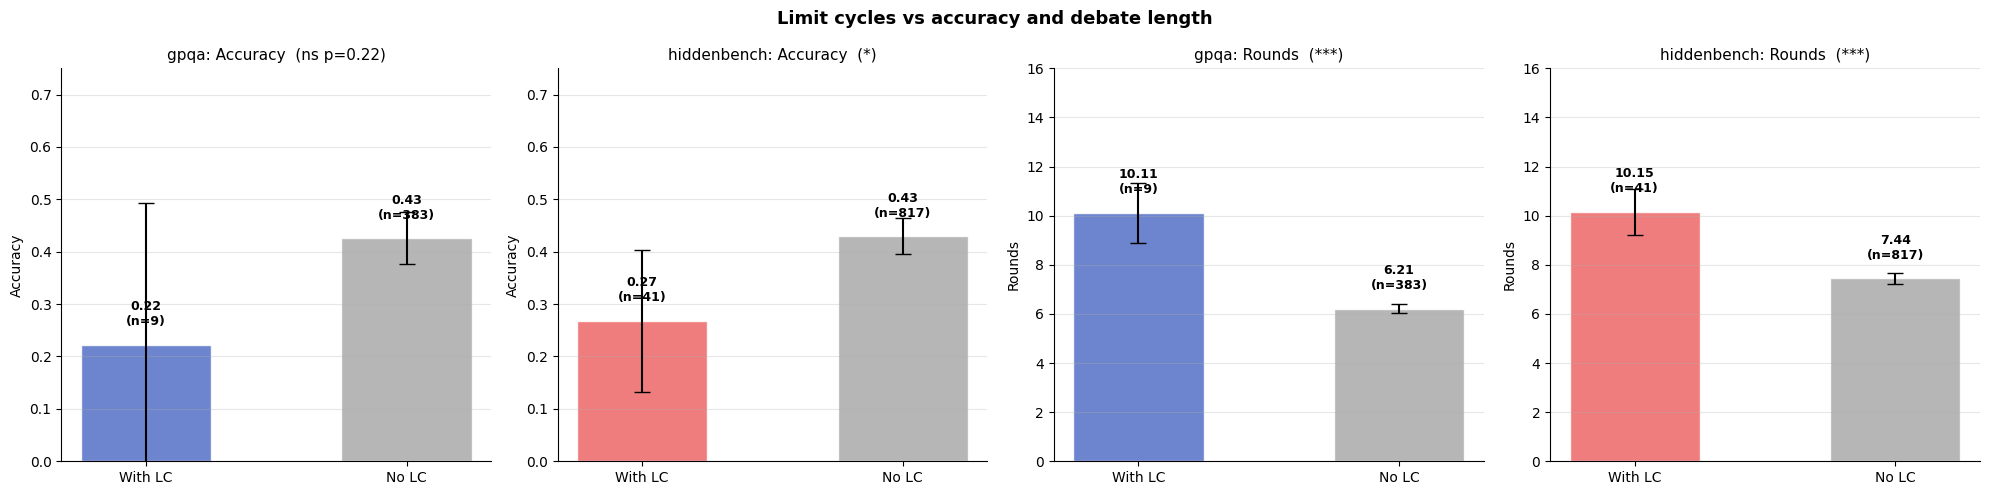

In [30]:
acc_df = df[df['final_correct'].notna()].copy()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for col, (feat, lbl, ylim) in enumerate([
    ('final_correct', 'Accuracy', (0, 0.75)),
    ('n_rounds',      'Rounds',   (0, 16)),
]):
    for ds_idx, ds in enumerate(datasets):
        ax  = axes[col * 2 + ds_idx]
        sub = acc_df[acc_df['dataset'] == ds] if feat == 'final_correct' else df[df['dataset'] == ds]
        lc_v  = sub[sub['lc'] == True][feat].astype(float).values
        nlc_v = sub[sub['lc'] == False][feat].astype(float).values
        ax.bar([0, 1], [lc_v.mean(), nlc_v.mean()],
               color=[DS_COLORS[ds], '#AAAAAA'], alpha=0.85, edgecolor='white', width=0.5)
        for i, vals in enumerate([lc_v, nlc_v]):
            se = vals.std() / np.sqrt(len(vals))
            ax.errorbar(i, vals.mean(), yerr=1.96 * se, fmt='none', color='black', capsize=6)
            ax.text(i, vals.mean() + ylim[1] * 0.05,
                    f'{vals.mean():.2f}\n(n={len(vals)})', ha='center', fontsize=9, fontweight='bold')
        _, p = sp_stats.ttest_ind(lc_v, nlc_v)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else f'ns p={p:.2f}'
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['With LC', 'No LC'], fontsize=10)
        ax.set_ylabel(lbl, fontsize=10)
        ax.set_ylim(*ylim)
        ax.set_title(f'{ds}: {lbl}  ({sig})', fontsize=11)
        ax.grid(axis='y', alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

fig.suptitle('Limit cycles vs accuracy and debate length', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()